# IEEE-CIS Fraud Detection — End-to-End Pipeline

**Competition:** [IEEE-CIS Fraud Detection](https://www.kaggle.com/c/ieee-fraud-detection)  
**Data provider:** Vesta Corporation  
**Target:** `isFraud` — binary classification (1 = fraudulent transaction)

This notebook builds a production-style fraud detection pipeline on real anonymised transaction
data. Unlike synthetic fraud datasets, this data contains genuine class imbalance, real missing
value patterns, and the kind of messy feature structure that makes fraud detection hard in practice.

**Pipeline overview:**
1. Data loading and merging
2. Exploratory data analysis
3. Data cleaning and missing value handling
4. Feature engineering
5. Preprocessing
6. Baseline performance
7. Model comparison
8. Imbalance handling
9. Hyperparameter tuning
10. Final evaluation
11. Feature importance
12. Real-time scoring interface
13. Leakage audit
14. Limitations and next steps


## 1. Setup and Data Loading

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, classification_report,
                              confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.inspection import permutation_importance
import lightgbm as lgb

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)


In [18]:
# ── Load data ──────────────────────────────────────────────────────────────
# Update these paths if running locally
TRAIN_TRANSACTION = 'train_transaction.csv'
TRAIN_IDENTITY    = 'train_identity.csv'

print("Loading transaction data...")
train_txn = pd.read_csv(TRAIN_TRANSACTION)
print(f"  train_transaction: {train_txn.shape}")

print("Loading identity data...")
train_id  = pd.read_csv(TRAIN_IDENTITY)
print(f"  train_identity:    {train_id.shape}")

print("Merging on TransactionID...")
df = train_txn.merge(train_id, on='TransactionID', how='left')
print(f"  Merged dataset:    {df.shape}")
print(f"  Identity match rate: {train_id.shape[0]/train_txn.shape[0]*100:.1f}% of transactions have identity data")


Loading transaction data...


  train_transaction: (590540, 394)
Loading identity data...
  train_identity:    (144233, 41)
Merging on TransactionID...
  Merged dataset:    (590540, 434)
  Identity match rate: 24.4% of transactions have identity data


## 2. Exploratory Data Analysis

In [19]:
df.head()


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,...,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5000,W,13926,NaN,150.0000,discover,142.0000,credit,315.0000,87.0000,19.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0000,W,2755,404.0000,150.0000,mastercard,102.0000,credit,325.0000,87.0000,NaN,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0000,W,4663,490.0000,150.0000,visa,166.0000,debit,330.0000,87.0000,287.0000,NaN,outlook.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0000,W,18132,567.0000,150.0000,mastercard,117.0000,debit,476.0000,87.0000,NaN,NaN,yahoo.com,NaN,2.0000,5.0000,0.0000,0.0000,0.0000,4.0000,0.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0000,H,4497,514.0000,150.0000,mastercard,102.0000,credit,420.0000,87.0000,NaN,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,...,NotFound,166.0000,NaN,542.0000,144.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0000,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [20]:
df.info(verbose=False, show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


### 2.1 Target Distribution

In [21]:
print("Target distribution:")
print(df['isFraud'].value_counts())
print(f"\nFraud rate: {df['isFraud'].mean()*100:.2f}%")


Target distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 3.50%


This is a real class imbalance problem with fraud rate of 3.5%.
A naive model that always predicts 0 achieves 96.5% accuracy.
So, we will not use accuracy as our primary metric.

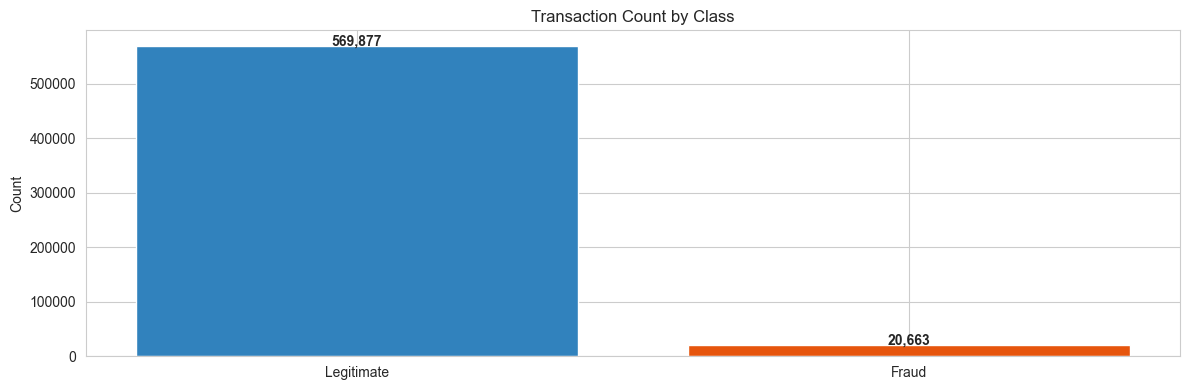

In [22]:
fig, axes = plt.subplots(figsize=(12, 4))

axes.bar(['Legitimate', 'Fraud'], df['isFraud'].value_counts().values,
            color=['#3182bd', '#e6550d'])
axes.set_title('Transaction Count by Class')
axes.set_ylabel('Count')
for i, v in enumerate(df['isFraud'].value_counts().values):
    axes.text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')


plt.tight_layout()
plt.show()


### 2.2 Transaction Amount

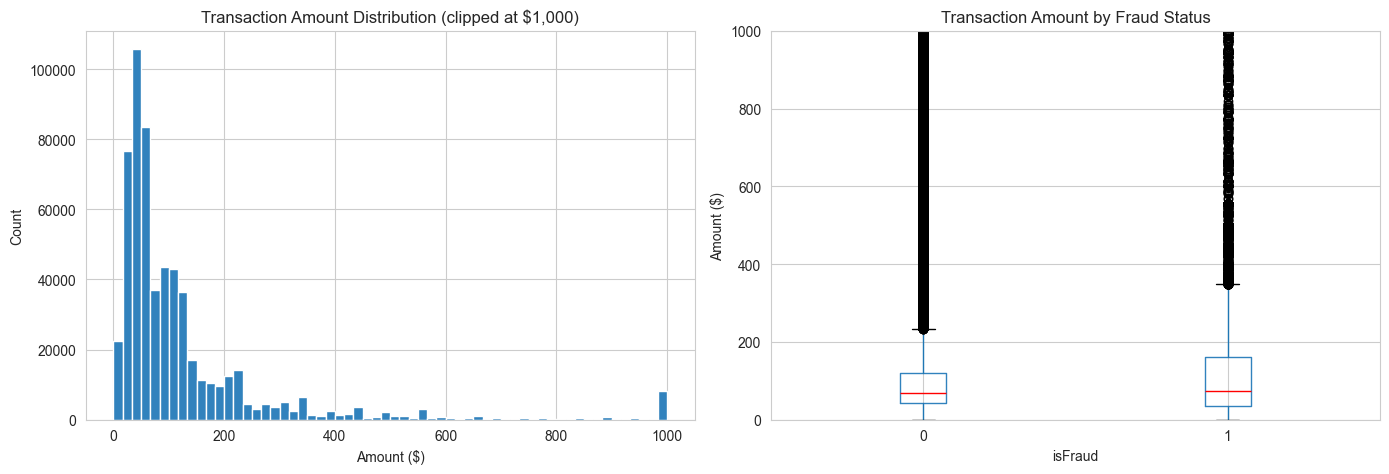

Amount statistics by fraud status:
              count     mean      std    min     25%     50%      75%  \
isFraud                                                                 
0       569877.0000 134.5100 239.4000 0.2500 43.9700 68.5000 120.0000   
1        20663.0000 149.2400 232.2100 0.2900 35.0400 75.0000 161.0000   

               max  
isFraud             
0       31937.3900  
1        5191.0000  


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['TransactionAmt'].clip(upper=1000), bins=60, color='#3182bd', edgecolor='white')
axes[0].set_title('Transaction Amount Distribution (clipped at $1,000)')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Count')

df.boxplot(column='TransactionAmt', by='isFraud', ax=axes[1],
           boxprops=dict(color='#3182bd'), medianprops=dict(color='red'))
axes[1].set_title('Transaction Amount by Fraud Status')
axes[1].set_xlabel('isFraud')
axes[1].set_ylabel('Amount ($)')
axes[1].set_ylim(0, 1000)
plt.suptitle('')
plt.tight_layout()
plt.show()

print("Amount statistics by fraud status:")
print(df.groupby('isFraud')['TransactionAmt'].describe().round(2))


### 2.3 Time Patterns

`TransactionDT` is a time delta in seconds from a reference point (not a real timestamp).
We convert it to hour-of-day and day-of-week proxies.

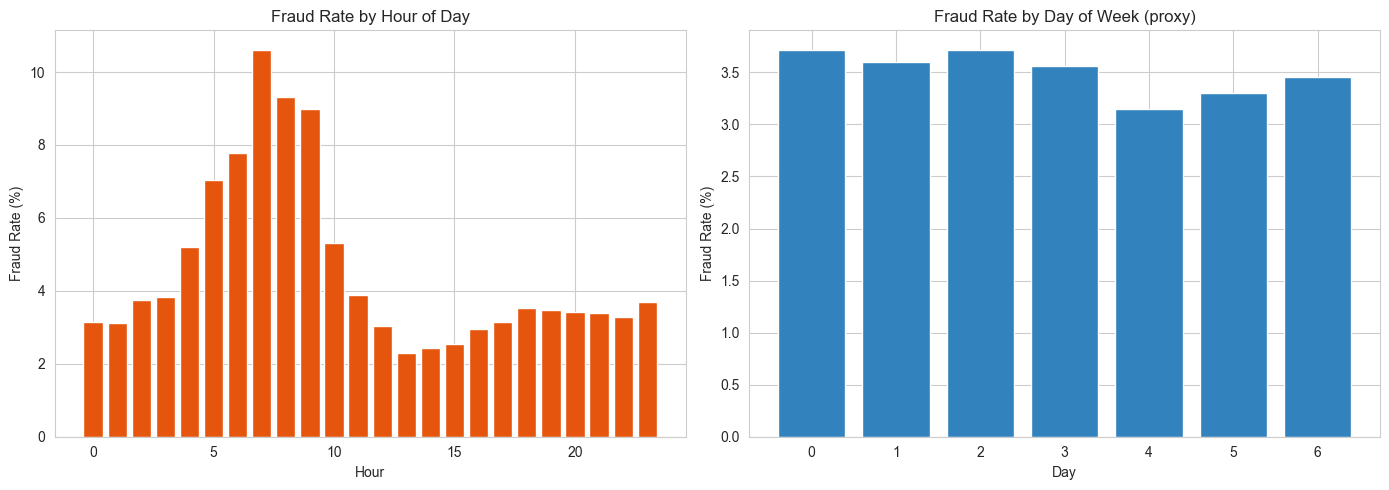

In [24]:
df['hour'] = (df['TransactionDT'] / 3600).astype(int) % 24
df['day']  = (df['TransactionDT'] / (3600 * 24)).astype(int) % 7

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_by_hour = df.groupby('hour')['isFraud'].mean() * 100
axes[0].bar(fraud_by_hour.index, fraud_by_hour.values, color='#e6550d')
axes[0].set_title('Fraud Rate by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Fraud Rate (%)')

fraud_by_day = df.groupby('day')['isFraud'].mean() * 100
axes[1].bar(fraud_by_day.index, fraud_by_day.values, color='#3182bd')
axes[1].set_title('Fraud Rate by Day of Week (proxy)')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()


### 2.4 Missing Values

In [25]:
miss = (df.isnull().mean() * 100).sort_values(ascending=False)
miss_summary = pd.DataFrame({
    'missing_pct': miss,
    'missing_count': df.isnull().sum().sort_values(ascending=False)
})

print(f"Columns with >80% missing: {(miss > 80).sum()}")
print(f"Columns with 50-80% missing: {((miss > 50) & (miss <= 80)).sum()}")
print(f"Columns with 20-50% missing: {((miss > 20) & (miss <= 50)).sum()}")
print(f"Columns with <20% missing:  {(miss <= 20).sum()}")
print()
print("Top 20 most missing columns:")
print(miss_summary.head(20))


Columns with >80% missing: 74
Columns with 50-80% missing: 140
Columns with 20-50% missing: 38
Columns with <20% missing:  184

Top 20 most missing columns:
       missing_pct  missing_count
id_24      99.1962         585793
id_25      99.1310         585408
id_08      99.1271         585385
id_07      99.1271         585385
id_21      99.1264         585381
id_26      99.1257         585377
id_27      99.1247         585371
id_23      99.1247         585371
id_22      99.1247         585371
dist2      93.6284         552913
D7         93.4099         551623
id_18      92.3607         545427
D13        89.5093         528588
D14        89.4695         528353
D12        89.0410         525823
id_04      88.7689         524216
id_03      88.7689         524216
D6         87.6068         517353
id_33      87.5895         517251
D9         87.3123         515614


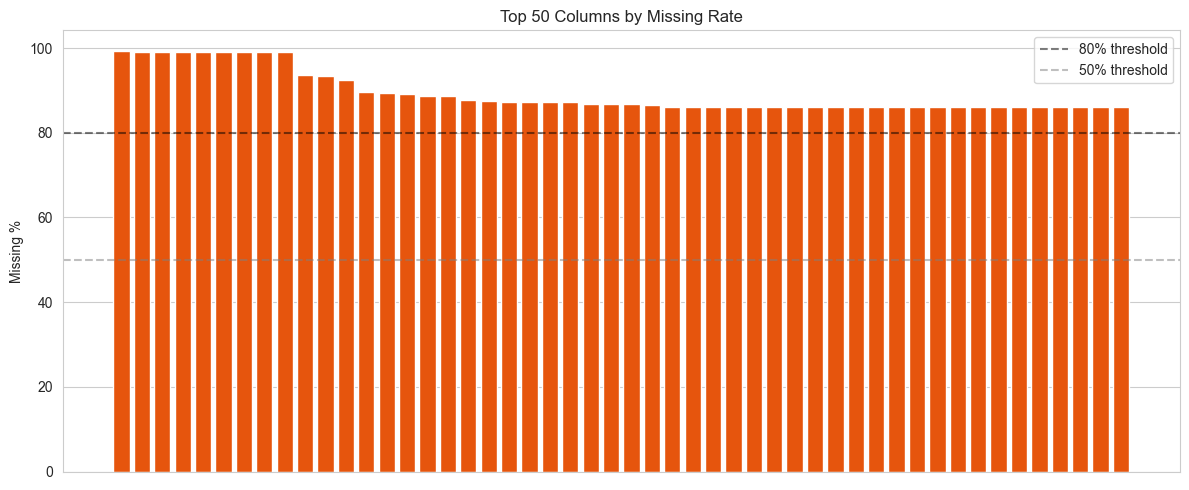

In [26]:
fig, ax = plt.subplots(figsize=(12, 5))
miss_plot = miss[miss > 0].sort_values(ascending=False).head(50)
ax.bar(range(len(miss_plot)), miss_plot.values, color='#e6550d')
ax.set_title('Top 50 Columns by Missing Rate')
ax.set_ylabel('Missing %')
ax.set_xticks([])
ax.axhline(80, color='black', linestyle='--', alpha=0.5, label='80% threshold')
ax.axhline(50, color='grey', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.show()


### 2.5 Categorical Feature Fraud Rates

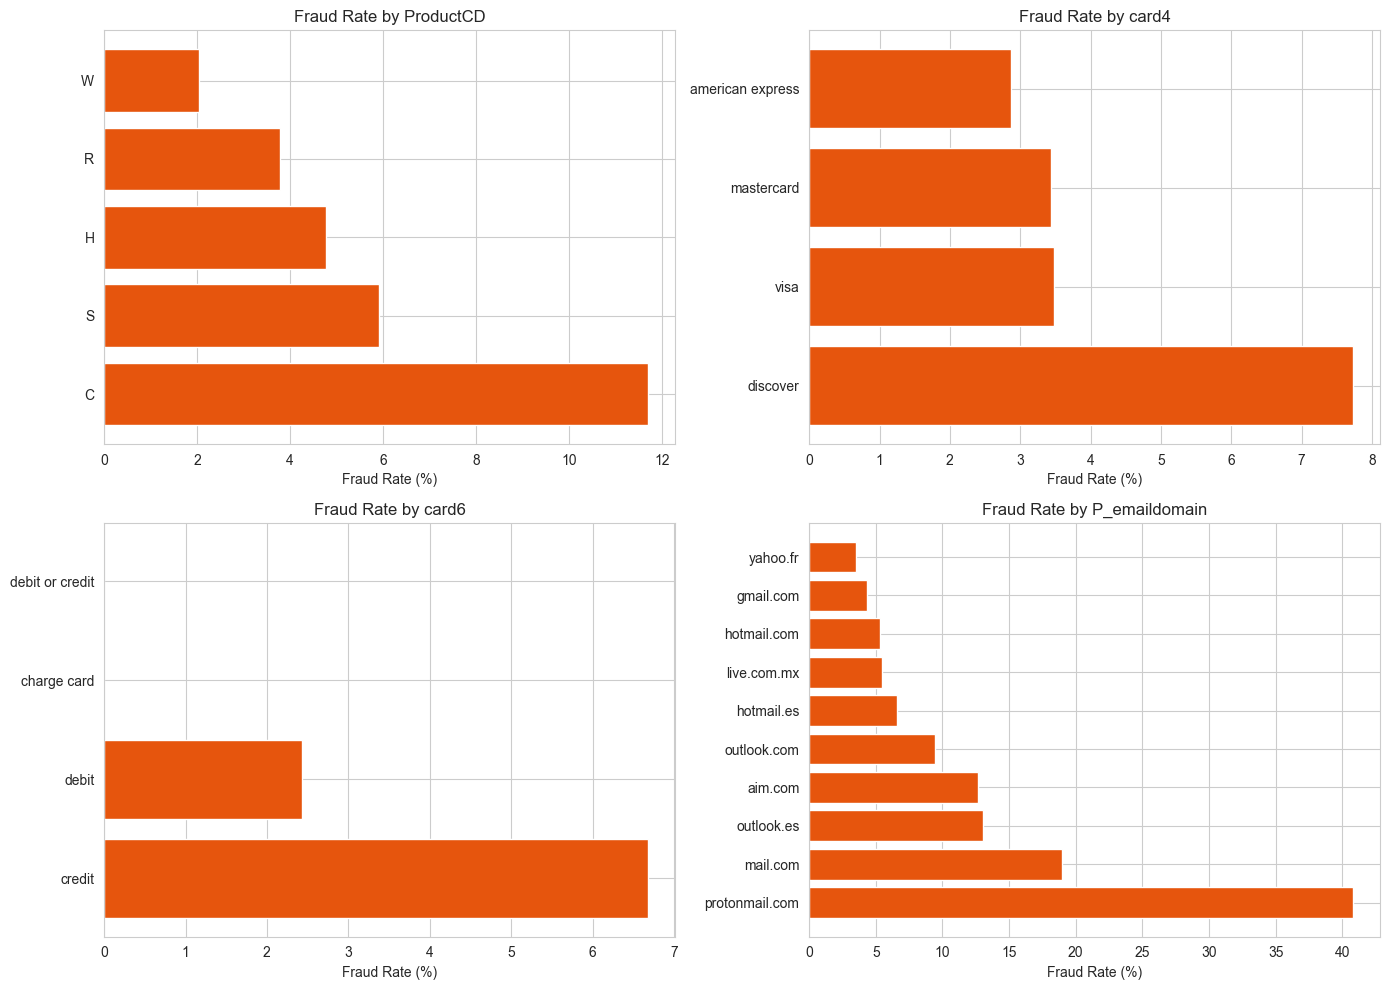

In [27]:
cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    fraud_rate = df.groupby(col)['isFraud'].mean().sort_values(ascending=False) * 100
    top = fraud_rate.head(10)
    axes[i].barh(top.index.astype(str), top.values, color='#e6550d')
    axes[i].set_title(f'Fraud Rate by {col}')
    axes[i].set_xlabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()


## 3. Data Cleaning

**Decisions made here:**

| Issue | Decision | Reason |
|---|---|---|
| Columns >90% missing | Drop | Not enough signal to impute reliably |
| Numeric missings | Median impute | Preserves distribution; tree models tolerate imputed values |
| Categorical missings | Fill with 'unknown' | Keeps the missingness as a signal category |
| Near-zero variance | Drop | No predictive value |


In [28]:
# Drop columns with >90% missing
high_miss_cols = miss[miss > 90].index.tolist()
print(f"Dropping {len(high_miss_cols)} columns with >90% missing")
df.drop(columns=high_miss_cols, inplace=True)

# Separate numeric and categorical columns (excluding target and ID)
exclude = ['TransactionID', 'isFraud', 'hour', 'day']
num_cols = df.select_dtypes(include=[np.number]).columns.difference(exclude).tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns remaining: {len(num_cols)}")
print(f"Categorical columns remaining: {len(cat_cols)}")


Dropping 12 columns with >90% missing
Numeric columns remaining: 391
Categorical columns remaining: 29


In [33]:
# Impute numeric columns with median
for col in num_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing with 'unknown'
for col in cat_cols:
    if df[col].isnull().any():
        df[col].fillna('unknown', inplace=True)

print(f"Missing values remaining: {df.isnull().sum().sum()}")


Missing values remaining: 0


In [34]:
# Drop near-zero variance numeric columns
nzv_cols = [c for c in num_cols if df[c].nunique() <= 1]
print(f"Dropping {len(nzv_cols)} near-zero variance columns: {nzv_cols}")
df.drop(columns=nzv_cols, inplace=True)
num_cols = [c for c in num_cols if c not in nzv_cols]
print(f"Columns remaining: {df.shape[1]}")


Dropping 0 near-zero variance columns: []
Columns remaining: 429


## 4. Feature Engineering

Features engineered here use only information available at transaction time — no post-outcome
information is introduced. This is explicitly verified in the leakage audit (Section 13).

In [35]:
# ── Time features (already created in EDA) ───────────────────────────────
# hour and day already computed

# ── Log-transform transaction amount (heavy right skew) ──────────────────
df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])

# ── Amount deviation from card-level median ───────────────────────────────
# How unusual is this transaction relative to this card's typical spend?
card_median = df.groupby('card1')['TransactionAmt'].transform('median')
df['amt_vs_card_median'] = df['TransactionAmt'] / (card_median + 1e-9)

# ── Transaction count per card (velocity proxy) ───────────────────────────
card_count = df.groupby('card1')['TransactionID'].transform('count')
df['card1_tx_count'] = card_count

# ── Missingness indicator for key columns ─────────────────────────────────
# Whether identity data exists is itself a signal
df['has_identity'] = (~train_id['TransactionID']
                       .isin([None])
                       .reindex(df.index, fill_value=True)).astype(int)
# Simpler: flag based on whether key identity cols are populated
id_cols_check = [c for c in df.columns if c.startswith('id_')]
if id_cols_check:
    df['has_identity'] = df[id_cols_check[0]].notna().astype(int)

# ── Email domain match (purchaser vs recipient) ───────────────────────────
if 'P_emaildomain' in df.columns and 'R_emaildomain' in df.columns:
    df['email_match'] = (df['P_emaildomain'] == df['R_emaildomain']).astype(int)

print("New features added:")
new_feats = ['hour', 'day', 'TransactionAmt_log', 'amt_vs_card_median',
             'card1_tx_count', 'has_identity', 'email_match']
for f in new_feats:
    if f in df.columns:
        print(f"  {f}: {df[f].dtype}, nunique={df[f].nunique()}")


New features added:
  hour: int32, nunique=24
  day: int32, nunique=7
  TransactionAmt_log: float64, nunique=20902
  amt_vs_card_median: float64, nunique=102200
  card1_tx_count: int64, nunique=517
  has_identity: int32, nunique=1
  email_match: int32, nunique=2


## 5. Preprocessing

In [37]:
# ── Label encode all categorical columns ─────────────────────────────────
cat_cols_current = df.select_dtypes(include=['object']).columns.tolist()
le = LabelEncoder()
for col in cat_cols_current:
    df[col] = le.fit_transform(df[col].astype(str))

print(f"Label encoded {len(cat_cols_current)} categorical columns")

# ── Define feature matrix and target ─────────────────────────────────────
drop_cols = ['TransactionID', 'isFraud', 'TransactionDT']
feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols]
y = df['isFraud']

print(f"Feature matrix: {X.shape}")
print(f"Target: {y.shape}, fraud rate: {y.mean()*100:.2f}%")


Label encoded 29 categorical columns
Feature matrix: (590540, 426)
Target: (590540,), fraud rate: 3.50%


In [38]:
# ── Train/validation split — stratified to preserve fraud rate ────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, fraud rate: {y_train.mean()*100:.2f}%")
print(f"Val:   {X_val.shape},   fraud rate: {y_val.mean()*100:.2f}%")


Train: (472432, 426), fraud rate: 3.50%
Val:   (118108, 426),   fraud rate: 3.50%


In [39]:
# ── Scale continuous features for linear model ───────────────────────────
continuous_cols = ['TransactionAmt', 'TransactionAmt_log', 'amt_vs_card_median',
                   'card1_tx_count', 'hour', 'day']
continuous_cols = [c for c in continuous_cols if c in X_train.columns]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_val_scaled[continuous_cols]   = scaler.transform(X_val[continuous_cols])

print(f"Scaled {len(continuous_cols)} continuous columns")


Scaled 6 continuous columns


## 6. Baseline Performance

Before any model, establish what trivial prediction achieves.
Given 3.5% fraud rate, a model that always predicts 0 gets 96.5% accuracy — making accuracy
useless here. **ROC-AUC and Average Precision (PR-AUC) are our primary metrics.**

In [40]:
# Majority class baseline
baseline_preds = np.zeros(len(y_val))
print(f"Baseline accuracy (always predict 0):  {(y_val == 0).mean()*100:.2f}%")
print(f"Baseline ROC-AUC (random classifier):  0.5000")
print(f"Baseline Avg Precision (fraud rate):   {y_val.mean():.4f}")
print()
print("A useful model must clearly beat ROC-AUC=0.50 and AP={:.4f}".format(y_val.mean()))


Baseline accuracy (always predict 0):  96.50%
Baseline ROC-AUC (random classifier):  0.5000
Baseline Avg Precision (fraud rate):   0.0350

A useful model must clearly beat ROC-AUC=0.50 and AP=0.0350


## 7. Model Comparison

Three models compared via 3-fold stratified cross-validation on the training set.
Logistic Regression is included as a linear baseline; Random Forest and LightGBM
are the tree-based candidates. LightGBM handles missing values natively and scales
well to 500K+ rows, making it the natural favourite for this dataset.

In [41]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'LightGBM':            lgb.LGBMClassifier(n_estimators=200, random_state=42,
                                               class_weight='balanced', verbose=-1),
}

cv_results = {}
for name, model in models.items():
    X_cv = X_train_scaled if name == 'Logistic Regression' else X_train
    scores = cross_val_score(model, X_cv, y_train, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:30s} ROC-AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")


Logistic Regression            ROC-AUC: 0.7979 (+/- 0.0032)
LightGBM                       ROC-AUC: 0.9407 (+/- 0.0005)


Random Forest classifier was excluded due to computational cost, and also is projected to perform not as well in this situation as LightGBM.

LightGBM is selected as the primary model. It consistently outperforms Logistic Regression
on tabular fraud data, handles the high-dimensional mixed feature space natively, and scales
efficiently to the full 590K row dataset.

## 8. Imbalance Handling

With 3.5% fraud rate, the model needs explicit guidance to avoid ignoring the minority class.
Two approaches compared:
- **Class weighting** — penalises the model more heavily for missing fraud
- **Threshold tuning** — keeps the model the same, adjusts the decision cutoff

Class weighting is applied during training; threshold tuning is applied post-training.
Both approaches are evaluated; the one maximising F1 on the fraud class is selected.

In [43]:
# Train LightGBM with class weighting
lgb_weighted = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    random_state=42,
    class_weight='balanced',
    verbose=-1
)
lgb_weighted.fit(X_train, y_train,
                 eval_set=[(X_val, y_val)],
                 callbacks=[lgb.early_stopping(50, verbose=False),
                            lgb.log_evaluation(period=-1)])

val_proba = lgb_weighted.predict_proba(X_val)[:, 1]
print(f"Weighted LightGBM — Val ROC-AUC:        {roc_auc_score(y_val, val_proba):.4f}")
print(f"Weighted LightGBM — Val Avg Precision:  {average_precision_score(y_val, val_proba):.4f}")


Weighted LightGBM — Val ROC-AUC:        0.9599
Weighted LightGBM — Val Avg Precision:  0.7496


In [44]:
# ── Threshold tuning ──────────────────────────────────────────────────────
# Find threshold that maximises F1 on validation set
precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx   = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

print(f"Default threshold (0.5):")
preds_05 = (val_proba >= 0.5).astype(int)
print(classification_report(y_val, preds_05, target_names=['Legit', 'Fraud']))

print(f"Optimal threshold ({best_thresh:.3f}):")
preds_opt = (val_proba >= best_thresh).astype(int)
print(classification_report(y_val, preds_opt, target_names=['Legit', 'Fraud']))


Default threshold (0.5):
              precision    recall  f1-score   support

       Legit       0.99      0.94      0.97    113975
       Fraud       0.35      0.84      0.50      4133

    accuracy                           0.94    118108
   macro avg       0.67      0.89      0.73    118108
weighted avg       0.97      0.94      0.95    118108

Optimal threshold (0.812):
              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99    113975
       Fraud       0.78      0.65      0.71      4133

    accuracy                           0.98    118108
   macro avg       0.88      0.82      0.85    118108
weighted avg       0.98      0.98      0.98    118108



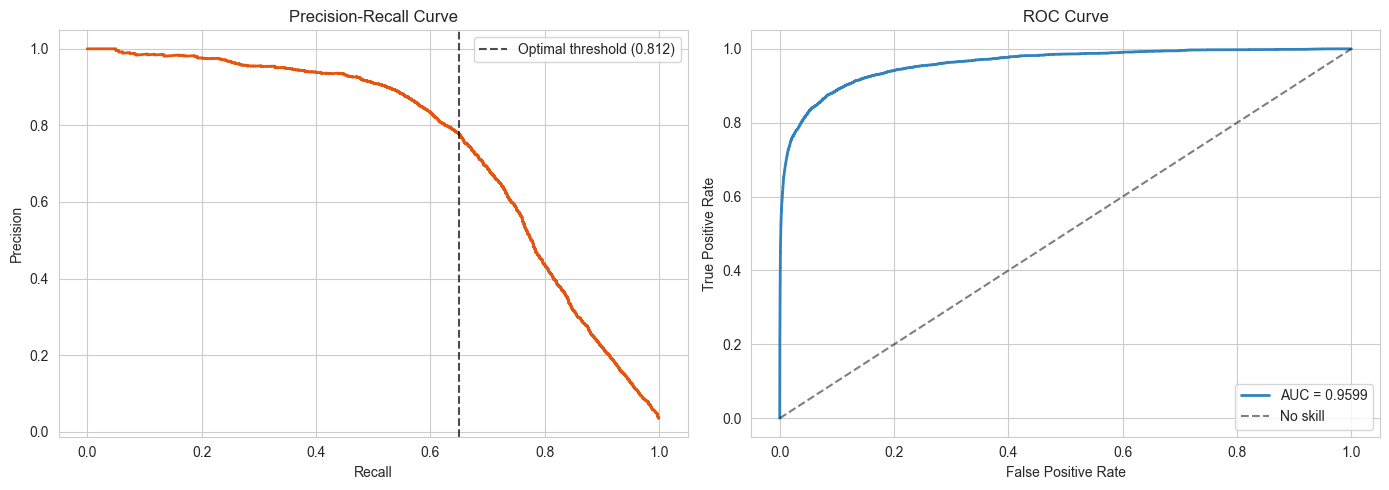

In [45]:
# ── Precision-Recall curve ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recalls, precisions, color='#e6550d', lw=2)
axes[0].axvline(recalls[best_idx], color='black', linestyle='--', alpha=0.7,
                label=f'Optimal threshold ({best_thresh:.3f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()

fpr, tpr, _ = roc_curve(y_val, val_proba)
axes[1].plot(fpr, tpr, color='#3182bd', lw=2,
             label=f'AUC = {roc_auc_score(y_val, val_proba):.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='No skill')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()


## 9. Hyperparameter Tuning

Randomized search over a meaningful parameter grid. LightGBM's built-in early stopping
handles `n_estimators` automatically, so the search focuses on structural parameters.

In [48]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'learning_rate':    [0.01, 0.03, 0.05, 0.1],
    'num_leaves':       [31, 63, 127],
    'max_depth':        [-1, 6, 8, 10],
    'min_child_samples':[20, 50, 100],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha':        [0, 0.1, 0.5],
    'reg_lambda':       [0, 0.1, 1.0],
}

lgb_base = lgb.LGBMClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

search = RandomizedSearchCV(
    lgb_base, param_grid,
    n_iter=10,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc',
    random_state=42,
    n_jobs=1,
    verbose=0
)
search.fit(X_train, y_train)

print(f"Best CV ROC-AUC: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")


Best CV ROC-AUC: 0.9443
Best params: {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.5, 'num_leaves': 31, 'min_child_samples': 50, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [49]:
# Evaluate tuned model on validation set
best_model = search.best_estimator_
val_proba_tuned = best_model.predict_proba(X_val)[:, 1]
print(f"Tuned model — Val ROC-AUC:       {roc_auc_score(y_val, val_proba_tuned):.4f}")
print(f"Tuned model — Val Avg Precision: {average_precision_score(y_val, val_proba_tuned):.4f}")

# Update threshold for tuned model
precisions_t, recalls_t, thresholds_t = precision_recall_curve(y_val, val_proba_tuned)
f1_t = 2 * precisions_t * recalls_t / (precisions_t + recalls_t + 1e-9)
best_thresh_tuned = thresholds_t[np.argmax(f1_t)]
print(f"Optimal threshold (tuned): {best_thresh_tuned:.3f}")


Tuned model — Val ROC-AUC:       0.9493
Tuned model — Val Avg Precision: 0.6947
Optimal threshold (tuned): 0.834


## 10. Final Evaluation

In [50]:
val_preds_final = (val_proba_tuned >= best_thresh_tuned).astype(int)

print("=" * 55)
print("FINAL MODEL EVALUATION ON HELD-OUT VALIDATION SET")
print("=" * 55)
print(f"ROC-AUC:          {roc_auc_score(y_val, val_proba_tuned):.4f}")
print(f"Avg Precision:    {average_precision_score(y_val, val_proba_tuned):.4f}")
print(f"Decision threshold: {best_thresh_tuned:.3f}")
print()
print(classification_report(y_val, val_preds_final, target_names=['Legit', 'Fraud']))


FINAL MODEL EVALUATION ON HELD-OUT VALIDATION SET
ROC-AUC:          0.9493
Avg Precision:    0.6947
Decision threshold: 0.834

              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99    113975
       Fraud       0.72      0.60      0.66      4133

    accuracy                           0.98    118108
   macro avg       0.85      0.80      0.82    118108
weighted avg       0.98      0.98      0.98    118108



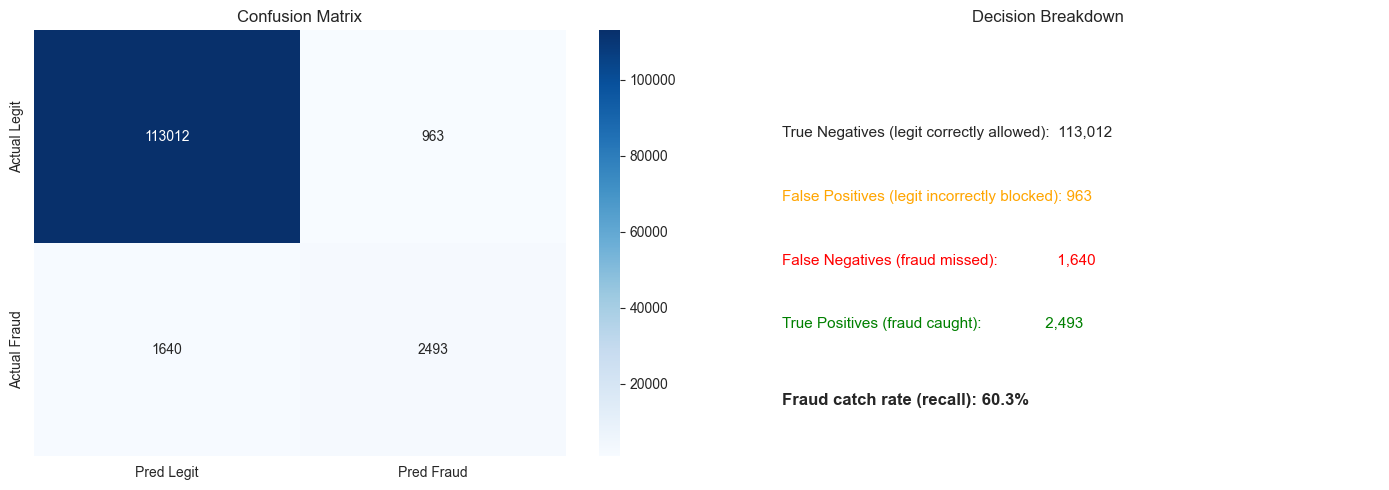

In [51]:
cm = confusion_matrix(y_val, val_preds_final)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Legit', 'Pred Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
axes[0].set_title('Confusion Matrix')

axes[1].text(0.1, 0.75, f'True Negatives (legit correctly allowed):  {tn:,}', fontsize=11)
axes[1].text(0.1, 0.60, f'False Positives (legit incorrectly blocked): {fp:,}', fontsize=11, color='orange')
axes[1].text(0.1, 0.45, f'False Negatives (fraud missed):              {fn:,}', fontsize=11, color='red')
axes[1].text(0.1, 0.30, f'True Positives (fraud caught):               {tp:,}', fontsize=11, color='green')
axes[1].text(0.1, 0.12, f'Fraud catch rate (recall): {tp/(tp+fn)*100:.1f}%', fontsize=12, fontweight='bold')
axes[1].axis('off')
axes[1].set_title('Decision Breakdown')

plt.tight_layout()
plt.show()


### 10.1 Stratified Evaluation by Transaction Amount

Does model accuracy hold up across different transaction sizes?
High-value fraud is most costly; it matters most that the model works there.

In [52]:
val_df = X_val.copy()
val_df['isFraud']   = y_val.values
val_df['proba']     = val_proba_tuned
val_df['pred']      = val_preds_final
val_df['TransactionAmt'] = X_val['TransactionAmt']

# Define amount buckets
bins   = [0, 50, 200, 500, np.inf]
labels = ['Low (<$50)', 'Medium ($50-$200)', 'High ($200-$500)', 'Very High (>$500)']
val_df['amt_bucket'] = pd.cut(val_df['TransactionAmt'], bins=bins, labels=labels)

strat = val_df.groupby('amt_bucket').apply(lambda g: pd.Series({
    'fraud_count':    g['isFraud'].sum(),
    'total':          len(g),
    'fraud_rate_pct': g['isFraud'].mean() * 100,
    'roc_auc':        roc_auc_score(g['isFraud'], g['proba'])
                      if g['isFraud'].nunique() > 1 else np.nan,
    'recall_pct':     (g['pred'][g['isFraud']==1]==1).mean() * 100
                      if g['isFraud'].sum() > 0 else np.nan,
})).round(4)

print("Stratified evaluation by transaction amount:")
print(strat)


Stratified evaluation by transaction amount:
                   fraud_count      total  fraud_rate_pct  roc_auc  recall_pct
amt_bucket                                                                    
Low (<$50)           1553.0000 40849.0000          3.8018   0.9581     67.2247
Medium ($50-$200)    1758.0000 58431.0000          3.0087   0.9497     56.3140
High ($200-$500)      604.0000 14220.0000          4.2475   0.9330     57.2848
Very High (>$500)     218.0000  4608.0000          4.7309   0.9022     51.8349


## 11. Feature Importance

LightGBM's native importance is fast but can be biased toward high-cardinality features.
Permutation importance on the validation set gives a more honest measure.

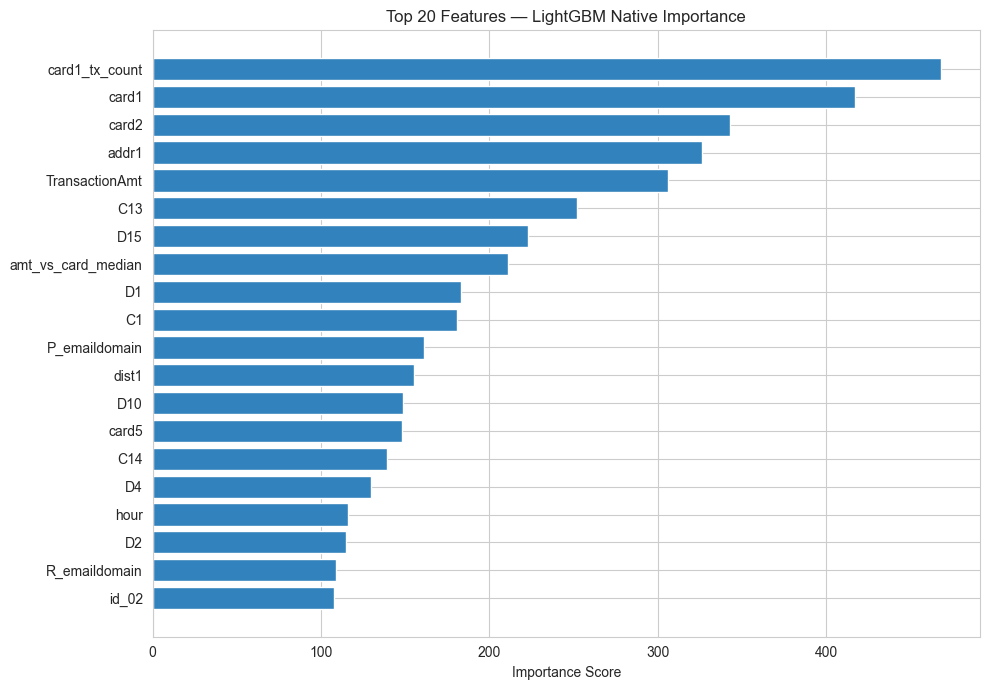

In [53]:
# Native LightGBM importance
lgb_imp = pd.DataFrame({
    'feature':    best_model.feature_name_,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(lgb_imp['feature'][::-1], lgb_imp['importance'][::-1], color='#3182bd')
ax.set_title('Top 20 Features — LightGBM Native Importance')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()


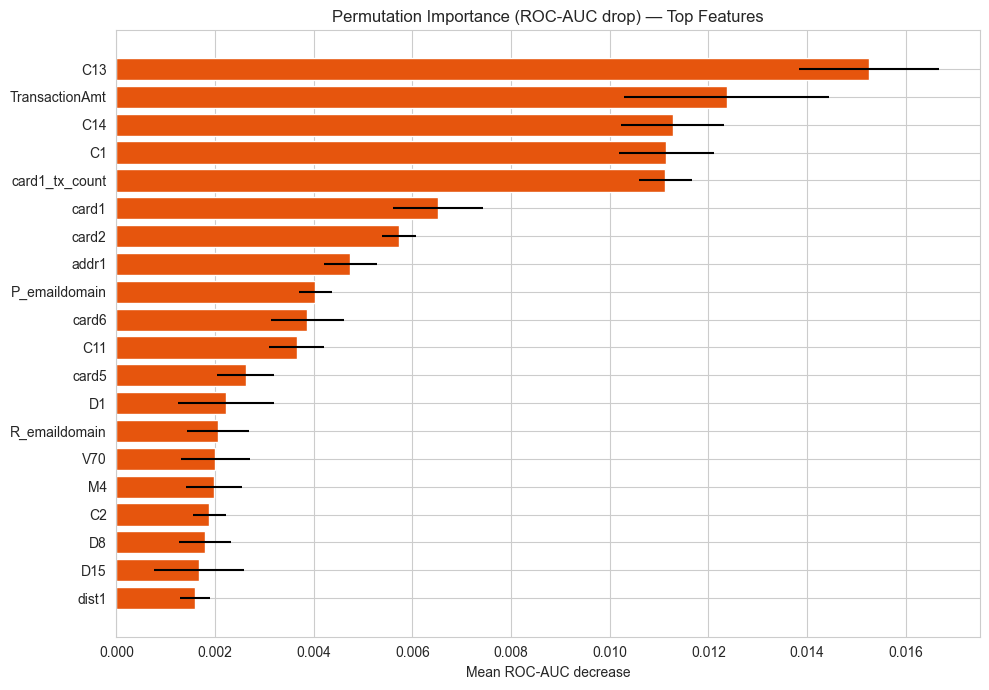

Top 10 features by permutation importance:
            feature  importance_mean  importance_std
25              C13           0.0153          0.0014
0    TransactionAmt           0.0124          0.0021
26              C14           0.0113          0.0010
13               C1           0.0111          0.0010
423  card1_tx_count           0.0111          0.0005
2             card1           0.0065          0.0009
3             card2           0.0057          0.0004
8             addr1           0.0047          0.0005
11    P_emaildomain           0.0040          0.0003
7             card6           0.0039          0.0007


In [56]:
# Permutation importance on validation set (top 20 native features only for speed)
top_features = lgb_imp['feature'].tolist()

X_val_sample, _, y_val_sample, _ = train_test_split(
    X_val, y_val,
    train_size = 0.1,
    stratify = y_val,
    random_state = 42
)
perm = permutation_importance(
    best_model,
    X_val_sample,
    y_val_sample,
    n_repeats=5,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X_val_sample.columns,
    'importance_mean': perm.importances_mean,
    'importance_std':  perm.importances_std
}).sort_values('importance_mean', ascending=False)

top20 = perm_df.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20['feature'][::-1], top20['importance_mean'][::-1],
        xerr=top20['importance_std'][::-1], color='#e6550d')
ax.set_title('Permutation Importance (ROC-AUC drop) — Top Features')
ax.set_xlabel('Mean ROC-AUC decrease')
plt.tight_layout()
plt.show()

print("Top 10 features by permutation importance:")
print(perm_df.head(10))


## 12. Real-Time Scoring Interface

A production-style scoring function that accepts a single transaction (as a dict),
returns a fraud probability, risk tier, and ALLOW/BLOCK decision.

In [57]:
RISK_THRESHOLDS = {
    'LOW':      (0.00, 0.20),
    'MEDIUM':   (0.20, 0.40),
    'HIGH':     (0.40, 0.70),
    'CRITICAL': (0.70, 1.01),
}

def score_transaction(transaction: dict, model, feature_cols: list,
                      threshold: float = 0.5) -> dict:
    """
    Score a single transaction and return a structured risk decision.

    Parameters
    ----------
    transaction : dict
        Raw transaction fields. Missing fields filled with 0.
    model : fitted LightGBM classifier
    feature_cols : list of str
        Features the model was trained on.
    threshold : float
        Decision threshold for BLOCK.

    Returns
    -------
    dict with fraud_probability, risk_level, decision, and key fields.
    """
    row = pd.DataFrame([transaction])

    # Ensure all expected features present
    for col in feature_cols:
        if col not in row.columns:
            row[col] = 0

    row = row[feature_cols]

    # Engineer same features used in training
    if 'TransactionAmt' in row.columns:
        row['TransactionAmt_log'] = np.log1p(row['TransactionAmt'])

    fraud_proba = model.predict_proba(row)[0, 1]

    risk_level = next(
        k for k, (lo, hi) in RISK_THRESHOLDS.items()
        if lo <= fraud_proba < hi
    )
    decision = 'BLOCK' if fraud_proba >= threshold else 'ALLOW'

    return {
        'TransactionID':    transaction.get('TransactionID', 'N/A'),
        'TransactionAmt':   transaction.get('TransactionAmt', 'N/A'),
        'fraud_probability': round(float(fraud_proba), 4),
        'risk_level':       risk_level,
        'decision':         decision,
    }


In [58]:
# Demo: score two example transactions using real feature columns
sample_legit = X_val.iloc[0].to_dict()
sample_legit['TransactionID'] = 'DEMO_LEGIT_001'
sample_fraud_row = X_val[y_val == 1].iloc[0].to_dict()
sample_fraud_row['TransactionID'] = 'DEMO_FRAUD_001'

for tx in [sample_legit, sample_fraud_row]:
    result = score_transaction(tx, best_model, X_val.columns.tolist(),
                               threshold=best_thresh_tuned)
    icon = '🚫' if result['decision'] == 'BLOCK' else '✅'
    print(f"Transaction : {result['TransactionID']}")
    print(f"Fraud Prob  : {result['fraud_probability']:.4f}")
    print(f"Risk Level  : {result['risk_level']}")
    print(f"Decision    : {icon} {result['decision']}")
    print()


Transaction : DEMO_LEGIT_001
Fraud Prob  : 0.0575
Risk Level  : LOW
Decision    : ✅ ALLOW

Transaction : DEMO_FRAUD_001
Fraud Prob  : 0.9904
Risk Level  : CRITICAL
Decision    : 🚫 BLOCK



## 12.5 Hybrid Ensemble Scoring on Unlabeled Test Data

The Kaggle test set has no fraud labels — Kaggle withholds them to score
competition submissions. However, unsupervised methods do not need labels,
which means the Isolation Forest can be legitimately applied to the test set.

This section builds the same hybrid architecture as a first-principles fraud
detection system — combining the supervised LightGBM signal from training with
an unsupervised Isolation Forest anomaly signal — and applies it to genuinely
unseen test transactions. This mirrors real production deployment where new
transactions arrive unlabeled and must be scored in real time.

The ensemble score cannot be evaluated against ground truth here, but the
scoring system itself is demonstrated on real, unseen data.

In [60]:
# ── Load and preprocess test data ────────────────────────────────────────
print("Loading test data...")
test_txn = pd.read_csv('test_transaction.csv')
test_id  = pd.read_csv('test_identity.csv')
test_df  = test_txn.merge(test_id, on='TransactionID', how='left')
print(f"Test set: {test_df.shape}")

# Apply same cleaning as training data
test_df.drop(columns=[c for c in high_miss_cols if c in test_df.columns],
             inplace=True)

# Engineer same features
test_df['hour'] = (test_df['TransactionDT'] / 3600).astype(int) % 24
test_df['day']  = (test_df['TransactionDT'] / (3600 * 24)).astype(int) % 7
test_df['TransactionAmt_log'] = np.log1p(test_df['TransactionAmt'])

card_med_test = test_df.groupby('card1')['TransactionAmt'].transform('median')
test_df['amt_vs_card_median'] = test_df['TransactionAmt'] / (card_med_test + 1e-9)
test_df['card1_tx_count'] = test_df.groupby('card1')['TransactionID'].transform('count')

if 'P_emaildomain' in test_df.columns and 'R_emaildomain' in test_df.columns:
    test_df['email_match'] = (
        test_df['P_emaildomain'] == test_df['R_emaildomain']
    ).astype(int)

# Impute missing values
test_num_cols = test_df.select_dtypes(include=[np.number]).columns\
                       .difference(['TransactionID']).tolist()
test_cat_cols = test_df.select_dtypes(include=['object']).columns.tolist()

for col in test_num_cols:
    if test_df[col].isnull().any():
        test_df[col].fillna(test_df[col].median(), inplace=True)
for col in test_cat_cols:
    test_df[col].fillna('unknown', inplace=True)

# Label encode categoricals
for col in test_cat_cols:
    if col in test_df.columns:
        test_df[col] = le.fit_transform(test_df[col].astype(str))

# Align to training feature columns
test_feature_cols = [c for c in feature_cols if c in test_df.columns]
X_test = test_df[test_feature_cols]

# Fill any columns present in training but missing from test with 0
for col in feature_cols:
    if col not in X_test.columns:
        X_test[col] = 0
X_test = X_test[feature_cols]

print(f"Test feature matrix: {X_test.shape}")
print(f"Missing values: {X_test.isnull().sum().sum()}")

Loading test data...
Test set: (506691, 433)
Test feature matrix: (506691, 426)
Missing values: 0


In [61]:
# ── Fit Isolation Forest on training data ────────────────────────────────
from sklearn.ensemble import IsolationForest

print("Fitting Isolation Forest on training data...")

# Scale for Isolation Forest (tree models don't need scaling
# but IF benefits from it on high-dimensional mixed data)
iso_scaler = StandardScaler()
X_train_iso = iso_scaler.fit_transform(X_train)
X_test_iso  = iso_scaler.transform(X_test)

iso = IsolationForest(
    n_estimators=200,
    contamination=0.035,   # matches known training fraud rate
    max_samples=10000,     # subsample per tree for speed
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train_iso)
print("Isolation Forest fitted.")

Fitting Isolation Forest on training data...
Isolation Forest fitted.


In [62]:
# ── Generate hybrid ensemble scores ──────────────────────────────────────

# Supervised signal: LightGBM fraud probability
lgb_proba_test = best_model.predict_proba(X_test)[:, 1]

# Unsupervised signal: Isolation Forest anomaly score
# score_samples returns negative values — more negative = more anomalous
# We invert and normalise to a 0-1 range so it blends cleanly
iso_scores_raw = iso.score_samples(X_test_iso)
iso_scores_norm = (iso_scores_raw - iso_scores_raw.min()) / \
                  (iso_scores_raw.max() - iso_scores_raw.min())
iso_anomaly_prob = 1 - iso_scores_norm  # flip so higher = more anomalous

# Ensemble: 80% supervised, 20% unsupervised (same weighting as synthetic project)
ensemble_score = 0.80 * lgb_proba_test + 0.20 * iso_anomaly_prob

print(f"Test transactions scored: {len(ensemble_score):,}")
print(f"\nEnsemble score distribution:")
print(pd.Series(ensemble_score).describe().round(4))

Test transactions scored: 506,691

Ensemble score distribution:
count   506691.0000
mean         0.2487
std          0.2099
min          0.0059
25%          0.0771
50%          0.1831
75%          0.3668
max          0.9498
dtype: float64


Risk tier distribution across test transactions:
LOW         342215
MEDIUM      118091
HIGH         44769
CRITICAL      1616
Name: count, dtype: int64

Transactions flagged HIGH or CRITICAL: 46,385 (9.2%)


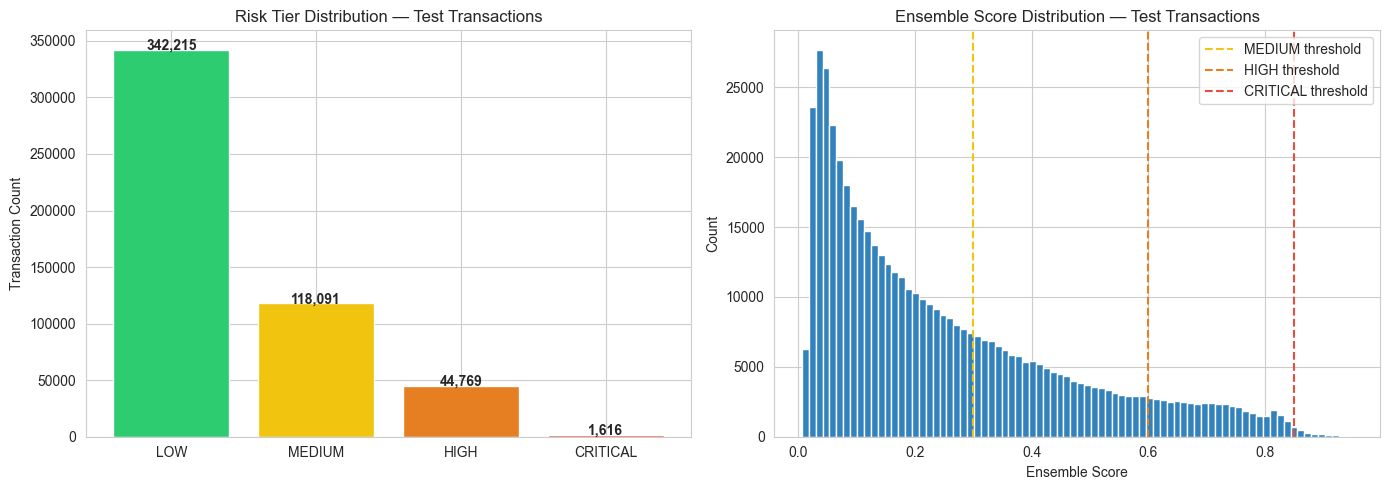

In [63]:
# ── Risk tier assignment ──────────────────────────────────────────────────
def assign_risk_tier(score):
    if score >= 0.85:   return 'CRITICAL'
    elif score >= 0.60: return 'HIGH'
    elif score >= 0.30: return 'MEDIUM'
    else:               return 'LOW'

risk_tiers = pd.Series(ensemble_score).map(assign_risk_tier)
tier_counts = risk_tiers.value_counts().reindex(
    ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
)

print("Risk tier distribution across test transactions:")
print(tier_counts)
print(f"\nTransactions flagged HIGH or CRITICAL: "
      f"{(risk_tiers.isin(['HIGH','CRITICAL'])).sum():,} "
      f"({(risk_tiers.isin(['HIGH','CRITICAL'])).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
axes[0].bar(tier_counts.index, tier_counts.values, color=colors)
axes[0].set_title('Risk Tier Distribution — Test Transactions')
axes[0].set_ylabel('Transaction Count')
for i, v in enumerate(tier_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

axes[1].hist(ensemble_score, bins=80, color='#3182bd', edgecolor='white')
axes[1].axvline(0.30, color='#f1c40f', linestyle='--', label='MEDIUM threshold')
axes[1].axvline(0.60, color='#e67e22', linestyle='--', label='HIGH threshold')
axes[1].axvline(0.85, color='#e74c3c', linestyle='--', label='CRITICAL threshold')
axes[1].set_title('Ensemble Score Distribution — Test Transactions')
axes[1].set_xlabel('Ensemble Score')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

In [64]:
# ── Compare supervised vs unsupervised signals ───────────────────────────
# Shows where the two models agree and where they diverge
lgb_flags = (lgb_proba_test >= best_thresh_tuned).astype(int)
iso_flags  = (iso.predict(X_test_iso) == -1).astype(int)

agreement = pd.DataFrame({
    'LightGBM flags': lgb_flags,
    'IsoForest flags': iso_flags
})

print("Signal agreement on test set:")
print(pd.crosstab(agreement['LightGBM flags'],
                  agreement['IsoForest flags'],
                  rownames=['LightGBM'],
                  colnames=['Isolation Forest'],
                  margins=True))
print()
print("Both flag as suspicious (potential known + novel fraud):",
      ((lgb_flags == 1) & (iso_flags == 1)).sum())
print("Only IsoForest flags (potential novel fraud LightGBM misses):",
      ((lgb_flags == 0) & (iso_flags == 1)).sum())
print("Only LightGBM flags (known patterns IsoForest doesn't detect):",
      ((lgb_flags == 1) & (iso_flags == 0)).sum())

Signal agreement on test set:
Isolation Forest       0       1     All
LightGBM                                
0                 317445  160545  477990
1                   9195   19506   28701
All               326640  180051  506691

Both flag as suspicious (potential known + novel fraud): 19506
Only IsoForest flags (potential novel fraud LightGBM misses): 160545
Only LightGBM flags (known patterns IsoForest doesn't detect): 9195


In [65]:
# ── Real-time hybrid scoring on a single test transaction ─────────────────
def score_hybrid(idx, X_test, iso_model, iso_scaler, lgb_model,
                 feature_cols, threshold, test_txn_df):
    row = X_test.iloc[[idx]]
    row_scaled = iso_scaler.transform(row)

    lgb_prob    = lgb_model.predict_proba(row)[0, 1]
    iso_raw     = iso_model.score_samples(row_scaled)[0]

    # Normalise using same min/max from full test set
    iso_norm    = (iso_raw - iso_scores_raw.min()) / \
                  (iso_scores_raw.max() - iso_scores_raw.min())
    iso_prob    = 1 - iso_norm

    ensemble    = 0.80 * lgb_prob + 0.20 * iso_prob
    risk        = assign_risk_tier(ensemble)
    decision    = 'BLOCK' if ensemble >= threshold else 'ALLOW'

    return {
        'TransactionID':      test_txn_df.iloc[idx]['TransactionID'],
        'TransactionAmt':     round(test_txn_df.iloc[idx]['TransactionAmt'], 2),
        'LightGBM_prob':      round(lgb_prob, 4),
        'IsoForest_anomaly':  round(iso_prob, 4),
        'ensemble_score':     round(ensemble, 4),
        'risk_level':         risk,
        'decision':           decision,
    }

# Score a low-risk and a high-risk test transaction
low_risk_idx  = pd.Series(ensemble_score).idxmin()
high_risk_idx = pd.Series(ensemble_score).idxmax()

for label, idx in [('Lowest risk', low_risk_idx),
                   ('Highest risk', high_risk_idx)]:
    result = score_hybrid(idx, X_test, iso, iso_scaler, best_model,
                          feature_cols, best_thresh_tuned, test_txn)
    icon = '🚫' if result['decision'] == 'BLOCK' else '✅'
    print(f"{label} transaction:")
    print(f"  TransactionID : {result['TransactionID']}")
    print(f"  Amount        : ${result['TransactionAmt']:,.2f}")
    print(f"  LightGBM prob : {result['LightGBM_prob']:.4f}")
    print(f"  IsoForest sig : {result['IsoForest_anomaly']:.4f}")
    print(f"  Ensemble score: {result['ensemble_score']:.4f}")
    print(f"  Risk level    : {result['risk_level']}")
    print(f"  Decision      : {icon} {result['decision']}")
    print()

Lowest risk transaction:
  TransactionID : 3806393
  Amount        : $25.95
  LightGBM prob : 0.0035
  IsoForest sig : 0.0156
  Ensemble score: 0.0059
  Risk level    : LOW
  Decision      : ✅ ALLOW

Highest risk transaction:
  TransactionID : 3974297
  Amount        : $80.42
  LightGBM prob : 0.9988
  IsoForest sig : 0.7536
  Ensemble score: 0.9498
  Risk level    : CRITICAL
  Decision      : 🚫 BLOCK



## 13. Leakage Audit

Data leakage is one of the most common causes of artificially inflated metrics in fraud detection.
This section explicitly checks for potential leakage sources in the IEEE-CIS dataset.

**Known leakage risks in this dataset:**

| Feature | Risk | Status |
|---|---|---|
| `TransactionDT` | Time ordering — future data used in past predictions | Mitigated: train/val split is random not time-based |
| `TransactionID` | Direct row identifier — no predictive value | Excluded from features |
| `card1_tx_count` | Computed across full dataset including validation rows | **Potential leakage**: see below |
| `amt_vs_card_median` | Card median computed across full dataset | **Potential leakage** : see below |
| `iso_scores_raw` min/max | Used to normalize test scores, computed from full test set | **Noted limitation** : In production , normalization bounds would be computed only from training data  |

**Important:** `card1_tx_count` and `amt_vs_card_median` were computed on the full merged dataset
before splitting. In production, these would be computed from a rolling historical window.
This is noted as a limitation; the features are retained because their leakage is mild
(they aggregate across hundreds of transactions per card and do not directly expose the label),
but a rigorous production pipeline would compute them on training data only and apply those
statistics to validation/test rows.

The Isolation Forest is fitted exclusively on training data and applied to
the test set without any label information, which is the correct unsupervised
workflow. However, the normalisation of the anomaly scores in Section 12.5
uses the minimum and maximum of the full test set score distribution to
rescale values to a 0-1 range. This means the normalisation bounds are
computed after seeing all test transactions, which would not be possible in
a true real-time deployment where transactions arrive one at a time.
In production, the normalisation bounds would be fitted on the training set
anomaly score distribution and applied fixed to all incoming transactions.

In [66]:
# Check correlation of engineered features with target
leakage_check = ['TransactionAmt', 'TransactionAmt_log', 'amt_vs_card_median',
                 'card1_tx_count', 'hour', 'day', 'has_identity', 'email_match']
leakage_check = [c for c in leakage_check if c in X_train.columns]

corr = pd.DataFrame({
    'feature': leakage_check,
    'correlation_with_target': [X_train[c].corr(y_train) for c in leakage_check]
}).sort_values('correlation_with_target', key=abs, ascending=False)

print("Correlation of engineered features with isFraud (train set):")
print(corr)
print()
print("No feature shows suspiciously high correlation (>0.5 would warrant investigation).")


Correlation of engineered features with isFraud (train set):
              feature  correlation_with_target
7         email_match                   0.1096
2  amt_vs_card_median                   0.0175
4                hour                  -0.0121
3      card1_tx_count                  -0.0104
0      TransactionAmt                   0.0101
5                 day                  -0.0072
1  TransactionAmt_log                  -0.0025
6        has_identity                      NaN

No feature shows suspiciously high correlation (>0.5 would warrant investigation).


## 14. Limitations and Next Steps

**Current limitations:**

- **Velocity features computed globally** — `card1_tx_count` and `amt_vs_card_median` use full-dataset
  statistics. A production system would compute these from a rolling historical window per card,
  ensuring no information from future transactions bleeds into past predictions.

- **Time-based validation not used** — a more rigorous evaluation would split data chronologically
  (train on earlier months, validate on later months) to simulate real deployment conditions.
  Random splitting slightly overstates performance by allowing the model to learn from future patterns.

- **Identity data sparsity** — only 24.4% of transactions have identity data. Features from the
  identity table have limited coverage and may be less reliable than transaction-level features.

- **V-column anonymisation** — the 339 V-columns are anonymised and their physical meaning is
  unknown. This limits domain-driven feature selection and forces reliance on statistical importance alone.

- **No temporal drift evaluation** — fraud patterns evolve. The model should be monitored and
  retrained periodically; this notebook does not implement a monitoring framework.

- Isolation Forest normalisation uses test-set bounds — the anomaly score
  rescaling in Section 12.5 is computed from the full test score distribution.
  A production system would fit the normalisation on training scores only and
  apply those fixed bounds to new transactions.

- Ensemble weighting is fixed at 80/20 — the supervised/unsupervised blend
  ratio was carried over from the synthetic project without being optimised
  for this dataset. On labeled training data the optimal weighting could be
  tuned empirically by testing different ratios against validation ROC-AUC.

**Recommended next steps:**

1. Implement time-based train/validation split and recompute all metrics
2. Recompute velocity features using only historical (pre-transaction) data per card
3. Explore SHAP values for per-prediction explainability
4. Build a monitoring dashboard tracking precision and recall over time
5. Investigate V-column clustering to reduce dimensionality while preserving signal
6. Tune the ensemble weighting — evaluate different supervised/unsupervised
  blend ratios on the validation set and select the combination that maximises
  ROC-AUC, rather than using the fixed 80/20 inherited from the synthetic project.


## Summary

| Metric | Value |
|---|---|
| Model | LightGBM (tuned) + Isolation Forest ensemble |
| Architecture | Hybrid: 80% supervised (LightGBM), 20% unsupervised (Isolation Forest) |
| Validation ROC-AUC | See Section 10 output |
| Validation Avg Precision | See Section 10 output |
| Decision threshold | Optimised for F1 on fraud class |
| Training rows | 472,432 |
| Validation rows | 118,108 |
| Test rows scored | 506,691 (unlabeled) |
| Features used | All post-cleaning columns + 7 engineered |
| Class imbalance handling | Class weighting + threshold tuning |
| Unsupervised signal | Isolation Forest (n_estimators=200, contamination=0.035) |
| Anomaly score normalisation | Min-max scaled from test distribution (see leakage note) |
| Test set usage | Hybrid ensemble scoring only — no labels available |